Original Values & Prediction Probabilities
        AW         Cost    Distance  Freighter_Prob  Narrowbody_Prob  Widebody_Prob Prediction     Actual
 1484.0000  12874.84000 6891.889528        0.058278     3.486880e-01       0.593034   Widebody   Widebody
  542.4900   6662.00000 5588.818227        0.094712     4.928113e-01       0.412477 Narrowbody Narrowbody
   72.0000   3257.76000 5268.287485        0.098758     5.483182e-01       0.352924 Narrowbody   Widebody
  196.0000  12395.01000 1331.011400        0.447075     4.496990e-01       0.103226 Narrowbody   Widebody
 3912.0000      0.00000 4810.704843        0.189372     2.611504e-01       0.549478   Widebody   Widebody
46752.0000 283321.36000 3004.285756        0.844042     1.948868e-08       0.155958  Freighter   Widebody
 7284.0000  28984.12000 4576.282272        0.296154     8.907171e-02       0.614774   Widebody  Freighter
 3012.0000      0.00000 4317.725947        0.219215     3.330836e-01       0.447701   Widebody   Widebody
 18

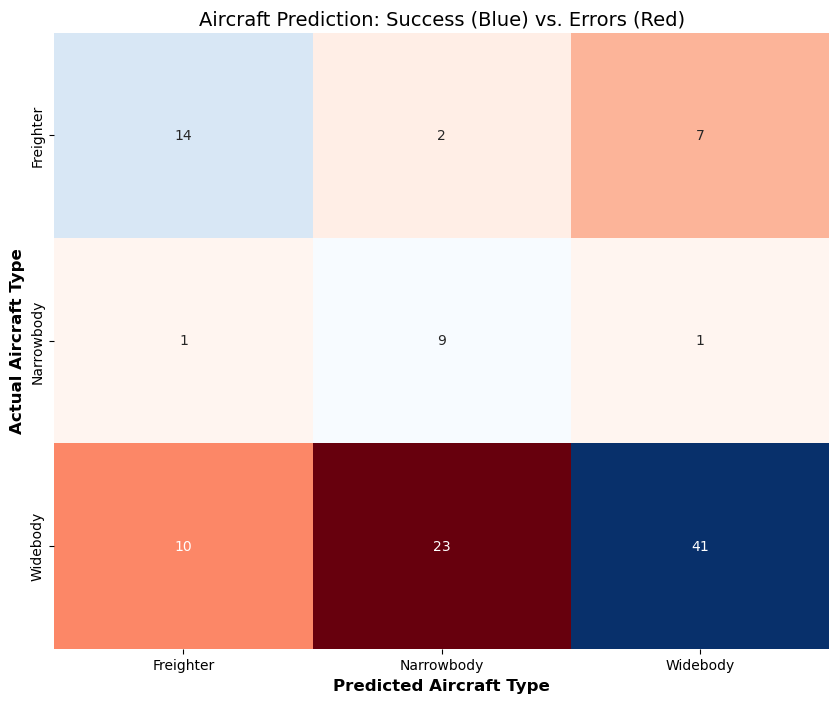

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

#Load dataset
df = pd.read_excel(r"C:\Users\bhara\Documents\Airlink project\MLRData.xlsx")

# X - independent variables, y - target variable
X = df[['AW', 'Cost', 'Distance']] 
y = df['Aircraft_Type']

# Target variable encoded
le = LabelEncoder()
y = le.fit_transform(y)

#Training, test set 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling of data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Fitting MNLR model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

#Probabilities
probs = model.predict_proba(X_test)

#Scaled X value back to original
X_test_original = scaler.inverse_transform(X_test)

#Creating dataframe
results_display = pd.DataFrame(X_test_original, columns=['AW', 'Cost', 'Distance'])

#Probability for each aircraft type
for i, class_name in enumerate(le.classes_):
    results_display[f'{class_name}_Prob'] = probs[:, i]

results_display['Prediction'] = le.inverse_transform(model.predict(X_test))
results_display['Actual'] = le.inverse_transform(y_test)

print("Original Values & Prediction Probabilities")
print(results_display.to_string(index=False))

#Accuracy test
accuracy = model.score(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2%}")

# Calculate baseline (what happens if we only predict the most common class?)
baseline_acc = df['Aircraft_Type'].value_counts(normalize=True).max()
print(f"Baseline Accuracy (Majority Class - Widebody): {baseline_acc:.2%}")

if accuracy < baseline_acc:
    print("Model is performing worse than baseline model with majority class (naive guess).")

#predictions for the test set
y_pred = model.predict(X_test)

print("\nDetailed Performance Metrics:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

#confusion matrix
cm = confusion_matrix(y_test, y_pred)

#masks for the diagonal and errors
mask_diagonal = np.eye(cm.shape[0], dtype=bool)
mask_off_diagonal = ~mask_diagonal

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            mask=mask_diagonal, xticklabels=le.classes_, yticklabels=le.classes_)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            mask=mask_off_diagonal, xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel('Predicted Aircraft Type', fontsize=12, fontweight='bold')
plt.ylabel('Actual Aircraft Type', fontsize=12, fontweight='bold')
plt.title('Aircraft Prediction: Success (Blue) vs. Errors (Red)', fontsize=14)
plt.show()

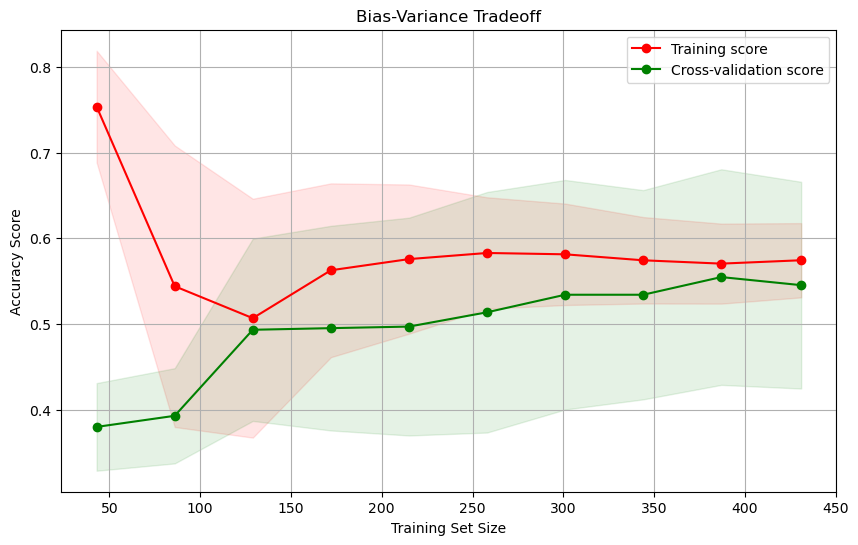

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Scaled independent variables
X_scaled_full = scaler.fit_transform(X) 

#Learning curve of data
train_sizes, train_scores, test_scores = learning_curve(
    model, X_scaled_full, y, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

#mean and standard deviation of dataset
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

#Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

#Variance shown using color coding
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Bias-Variance Tradeoff")
plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc="best")
plt.grid()
plt.show()